# ECG data processing pipeline

## Analysis plan

**Starting point:** The file `ECGu.txt` contains 6,500 rows and three columns of raw ECG measurements.

**Final goal:** Display the ECG signals with amplitude in millivolts and time in seconds.

The analysis will follow these steps:

1. Import the necessary libraries.
2. Load the raw ECG data.
3. Check the values and dimensions of the data.
4. Plot the raw ECG data.
5. Convert the ECG amplitude into millivolts.
6. Create a time axis in seconds.
7. Plot the rescaled ECG signals.
8. Improve the readability of the code.
9. Create a realistic ECG plot for the optional bonus.

## Load the ECG data

The ECG data must first be loaded into Python so that its values and dimensions can be checked before further analysis.

In [9]:
# Cell 1: imports

# import the necessary libraries for analysis

import numpy as np # NumPy allows for numerical analysis and calculations and its name is shortened to np. 
import matplotlib.pyplot as plt #  The pyplot tool is accessed through Matplotlib and is used to plot/graph the data and is shortened to plt. 

In [10]:
# CELL 2: load the data into a numpy array

# create a variable called data_path to store the path of the data file
data_path = "data/ECGu.txt" #this is the path to locate the data file
raw_ecg_data = np.loadtxt(data_path) # np.loadtxt() loads numerical data from a text file into a NumPy array # https://numpy.org/doc/stable/reference/generated/numpy.loadtxt.html

In [12]:
# Cell 3: look at the data (verify that the data is loaded correctly)

print(raw_ecg_data)
print(raw_ecg_data.shape) #shape tells you the dimensions of the loaded data. 6500 rows = 6,500 recorded samples, 3 columns = three ECG columns/leads: I, II and III.

#  When Python displays the array, it hides most of the rows using ..., so you cannot count them visually. .shape lets you verify that the complete file was loaded correctly.


[[-275. -119. -119.]
 [-275. -119. -119.]
 [-275. -118. -121.]
 ...
 [  -4.  -83.   21.]
 [  -9.  -88.   31.]
 [ -16.  -96.   33.]]
(6500, 3)


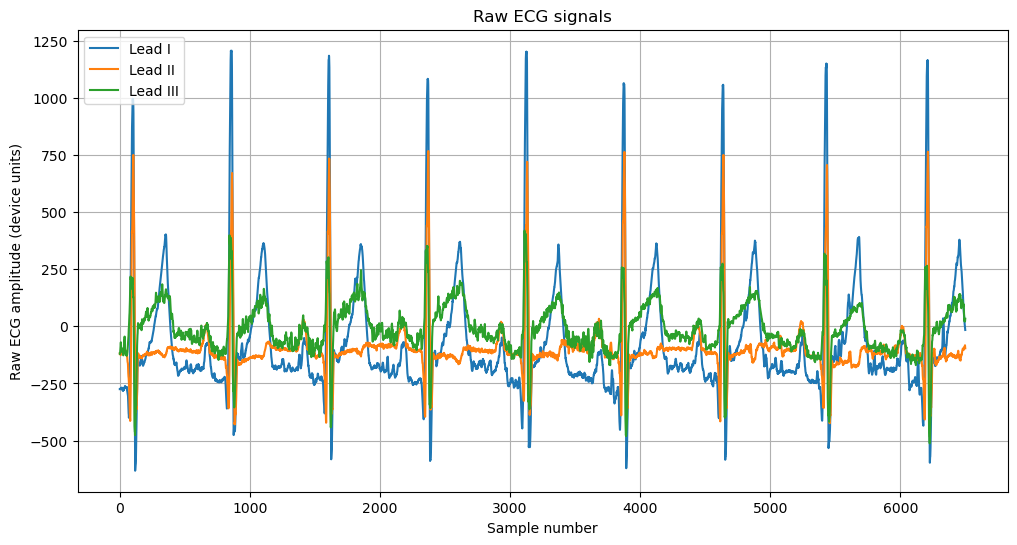

In [ ]:
# Cell 1: Plot the raw ECG data that was loaded in the previous step.

# Resources: 
    # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.plot.html
    # https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.legend.html

# Plot a new figure that is 12 inches wide and 6 inches high.
plt.figure(figsize=(12, 6))

# Plot every row from the 3 coloumns of ECG data. 
plt.plot(raw_ecg_data[:, 0], label="Lead I") # Plot every row in column 0, for representing Lead I. [:, 0] means all rows from the 1st column (Python counts from zero). Label is displayed in the legend.

plt.plot(raw_ecg_data[:, 1], label="Lead II") # Plot every row in column 1, representing Lead II. [:, 1] means all rows from the 2nd column. Label is displayed in the legend.

plt.plot(raw_ecg_data[:, 2], label="Lead III") # Plot every row in column 2, representing Lead III. [:, 2] means all rows from the 3rd column. Label is displayed in the legend.

# create the x-axis and y-axis labels for the graph
plt.xlabel("Sample number")
plt.ylabel("Raw ECG amplitude (device units)")

# create the title, legend, and grid for the graph
plt.title("Raw ECG signals")
plt.legend()
plt.grid()

plt.show() # displays the completed graph

## Checking that the raw ECG plot is correct

The plot appears correct because it shows three lines, corresponding to the three columns in the dataset and the three recorded ECG leads: I, II, and III. The x-axis runs from 0 to 6,499 and is labeled as "Sample number" which is consistent with the 6,500 rows in the data (the 6,500th row is empty in the data set). 

The signals also contain repeating peaks and patterns rather than remaining constant. The y-axis is still expressed in raw device units because the ECG amplitude has not yet been converted into millivolts.

## Convert the ECG amplitude to millivolts

The ECG values are currently expressed in raw device units. According to the A/D converter gain provided in the instructions, 1,024 raw units correspond to 1 millivolt. The raw values must therefore be divided by 1,024.

$ECG_{mV}$ = $ECG_{raw}$ × 1024 $μV$
 

In [ ]:
# Store the converter gain: 1,024 raw units correspond to 1 millivolt.
converter_gain = 1024

# Divide every raw ECG value by the gain to convert it to millivolts.
ecg_data_mv = raw_ecg_data / converter_gain # create a new variable called ecg_data_mv to store the answer 

# Display the converted data to check the result.
ecg_data_mv